### Practice Exercise (Polynomial Regression)

In [48]:
from pathlib import Path
import sys

current_dir = Path.cwd()
project_root = current_dir.parent.absolute()

sys.path.insert(0,str(project_root))

from config import S_PL_EX

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [50]:
#loading the dataset
df = pd.read_csv(S_PL_EX)
print(f'Shape of the Dataset: {df.shape}')
print(f'Missing values in each columns\n{df.isnull().sum()}')

Shape of the Dataset: (22, 2)
Missing values in each columns
Temperature      0
IceCreamSales    0
dtype: int64


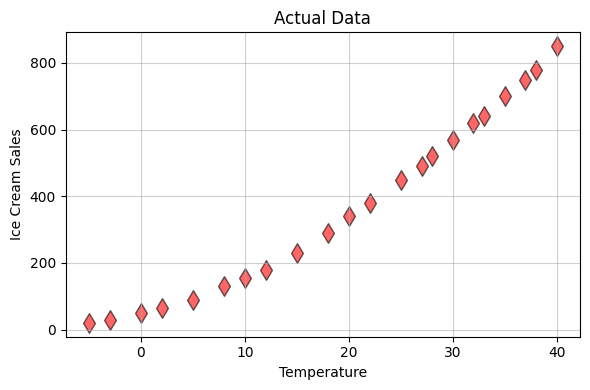

In [51]:
#visualization of data
plt.figure(figsize=(6,4))
plt.scatter(df['Temperature'],df['IceCreamSales'],s=100,marker='d', color='r',edgecolors='black',alpha=0.6)
plt.xlabel('Temperature')
plt.ylabel('Ice Cream Sales')
plt.title('Actual Data')
plt.grid(True,alpha=0.6)
plt.tight_layout()
plt.show()

In [52]:
X = df[['Temperature']].values
y = df['IceCreamSales']

In [53]:
# training the linear model
from sklearn.linear_model import LinearRegression
ln = LinearRegression()

ln.fit(X,y)
pred_y_ln = ln.predict(X)

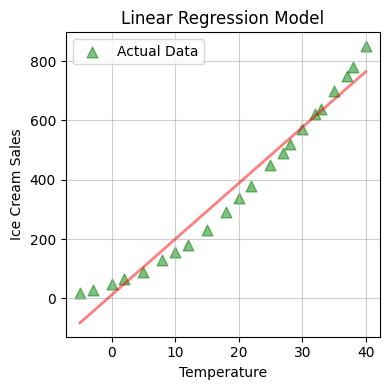

In [54]:
##visualization of the linear model
plt.figure(figsize=(4,4))
plt.scatter(X,y,marker='^',s=60, color='green',label='Actual Data',alpha=0.5)
plt.plot(X,pred_y_ln,linewidth=2,color='r',alpha=0.5)
plt.xlabel('Temperature')
plt.ylabel('Ice Cream Sales')
plt.title('Linear Regression Model')
plt.grid(True,alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

In [55]:
#polynomial regressioin
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

X_range = np.linspace(X.min(),X.max(),300).reshape(-1,1)
results = {
    'linear' : pred_y_ln
}
prediction_smooth = {
    'linear' : ln.predict(X_range)
}

colors_map = {
    'linear' : 'r',
    'degree 2' : 'blue',
    'degree 3' : 'green',
    'degree 4' : 'pink'
}

for degree in [2,3,4]:
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X)
    X_range_poly = poly.transform(X_range)

    poly_ln =LinearRegression()
    poly_ln.fit(X_poly,y)

    y_pred = poly_ln.predict(X_poly)
    y_pred_poly = poly_ln.predict(X_range_poly)

    labels = f'degree {degree}'
    results[labels] = (
        y_pred
    )

    prediction_smooth[labels] = (
        poly_ln.predict(X_range_poly)
    )

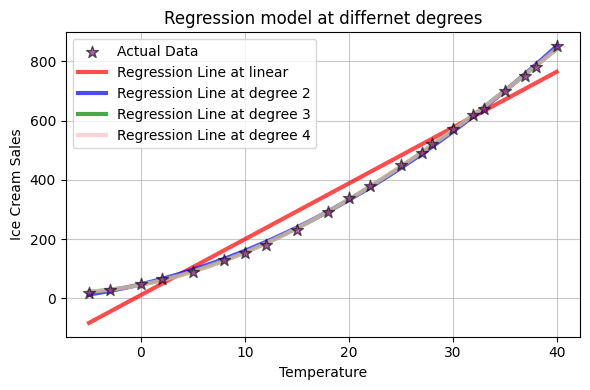

In [61]:
plt.figure(figsize=(6,4))
plt.scatter(X,y,label='Actual Data',s=80, marker='*',edgecolors='black',color='purple', alpha=0.6, zorder=5)


for label, smooth_pred in prediction_smooth.items():
    plt.plot(X_range,smooth_pred,linewidth=3,color=colors_map[label],alpha=0.7,label=f'Regression Line at {label}')
    plt.xlabel('Temperature')
    plt.ylabel('Ice Cream Sales')
    plt.title('Regression model at differnet degrees')
    plt.grid(True,alpha=0.7)
    plt.legend()
plt.tight_layout()
plt.show()